# Sensor Logger Exploration Script

Each folder in `DATA/` is one recording made with the *Sensor Logger* app (see `Metadata.csv`).
A folder contains one CSV per sensor stream (`time`, `seconds_elapsed`, `x`, `y`, `z`) plus a
photo of the location where the recording was made.

This notebook:

1. discovers every dataset folder and loads its CSVs, metadata and photo;
2. prints a summary table;
3. for every dataset, shows the location photo next to the time series of each sensor;
4. compares all datasets side by side (photo + acceleration magnitude).


In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

DATA_DIR = Path("DATA")
FIG_DIR = Path("figures")          # exported folder
FIG_DIR.mkdir(exist_ok=True)

# Sensor streams to plot with  unit
SENSORS = {
    "Accelerometer":                "m/s2 (gravity removed)",
    "TotalAcceleration":            "m/s2",
    "Gravity":                      "m/s2",
    "Gyroscope":                    "rad/s",
    "AccelerometerUncalibrated":    "m/s2",
    "GyroscopeUncalibrated":        "rad/s",
}

# Categorical colours (blue / orange / aqua)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]
AXIS_COLORS = dict(zip("xyz", PALETTE))

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.2,
    "font.family": "sans-serif",
})


## 1. Load every dataset folder

In [7]:
def load_dataset(folder: Path) -> dict:
    """Load one recording folder: metadata, sensor CSVs and the location photo."""
    meta = pd.read_csv(folder / "Metadata.csv").iloc[0].to_dict()

    sensors = {}
    for name in SENSORS:
        csv = folder / f"{name}.csv"
        if csv.exists():
            df = pd.read_csv(csv)
            df["t"] = df["seconds_elapsed"]
            sensors[name] = df

    photos = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png")))
    photo = None
    if photos:
        photo = ImageOps.exif_transpose(Image.open(photos[0]))
        photo.thumbnail((1200, 1200))   #to keep notebook light

    start = pd.to_datetime(meta["recording epoch time"], unit="ms", utc=True).tz_convert(meta["recording timezone"])
    return {
        "name": folder.name,
        "folder": folder,
        "meta": meta,
        "start": start,
        "sensors": sensors,
        "photo": photo,
        "photo_name": photos[0].name if photos else None,
    }


datasets = [load_dataset(d) for d in sorted(DATA_DIR.iterdir()) if d.is_dir()]
print(f"Loaded {len(datasets)} datasets:", [d["name"] for d in datasets])


Loaded 6 datasets: ['2026-09-08_06-20-20', '2026-09-08_15-23-11', '2026-09-11_08-36-17', '2026-09-11_08-37-23', '2026-09-11_08-41-47', '2026-09-12_11-49-51']


## 2. Summary of the recordings

Note on the sample rate: `Metadata.csv` says `sampleRateMs = 10` (100 Hz requested), but the
timestamps show the phone actually delivers one sample every 18.85 ms (~53 Hz). Android snaps the
requested rate to a rate the sensor hardware supports apperently. 


In [8]:
rows = []
for d in datasets:
    acc = d["sensors"].get("Accelerometer")
    rows.append({
        "dataset": d["name"],
        "start (local)": d["start"].strftime("%Y-%m-%d %H:%M:%S"),
        "duration [s]": round(acc["t"].iloc[-1] - acc["t"].iloc[0], 2) if acc is not None else None,
        "samples (Accelerometer)": len(acc) if acc is not None else 0,
        "nominal rate [Hz]": round(1 / np.median(np.diff(acc["t"])), 1) if acc is not None else None,
        "requested [ms]": d["meta"]["sampleRateMs"].split("|")[0],
        "device": d["meta"]["device name"],
        "photo": d["photo_name"],
    })
summary = pd.DataFrame(rows)
summary


,dataset,start (local),duration [s],samples (Accelerometer),nominal rate [Hz],requested [ms],device,photo
0,2026-09-08_06-20-20,2026-09-08 08:20:20,133.83,13341,99.7,10,iPhone 11,8 september coming from home.jpg
1,2026-09-08_15-23-11,2026-09-08 17:23:11,78.37,7814,99.7,10,iPhone 11,unnamed.jpg
2,2026-09-11_08-36-17,2026-09-11 10:36:17,39.41,2051,53.1,10,SM-G780G,20260911_104010.jpg
3,2026-09-11_08-37-23,2026-09-11 10:37:23,28.17,1464,53.0,10,SM-G780G,20260911_103717.jpg
4,2026-09-11_08-41-47,2026-09-11 10:41:47,37.20,1904,53.0,10,SM-G780G,20260911_104142.jpg
5,2026-09-12_11-49-51,2026-09-12 13:49:51,80.57,8033,99.7,10,iPhone 11,unnamed.jpg


## 3. Dataset Visualization

- **Left**: the photo taken at the recording location. 
- **Right**: x/y/z of every sensor stream against
elapsed time.

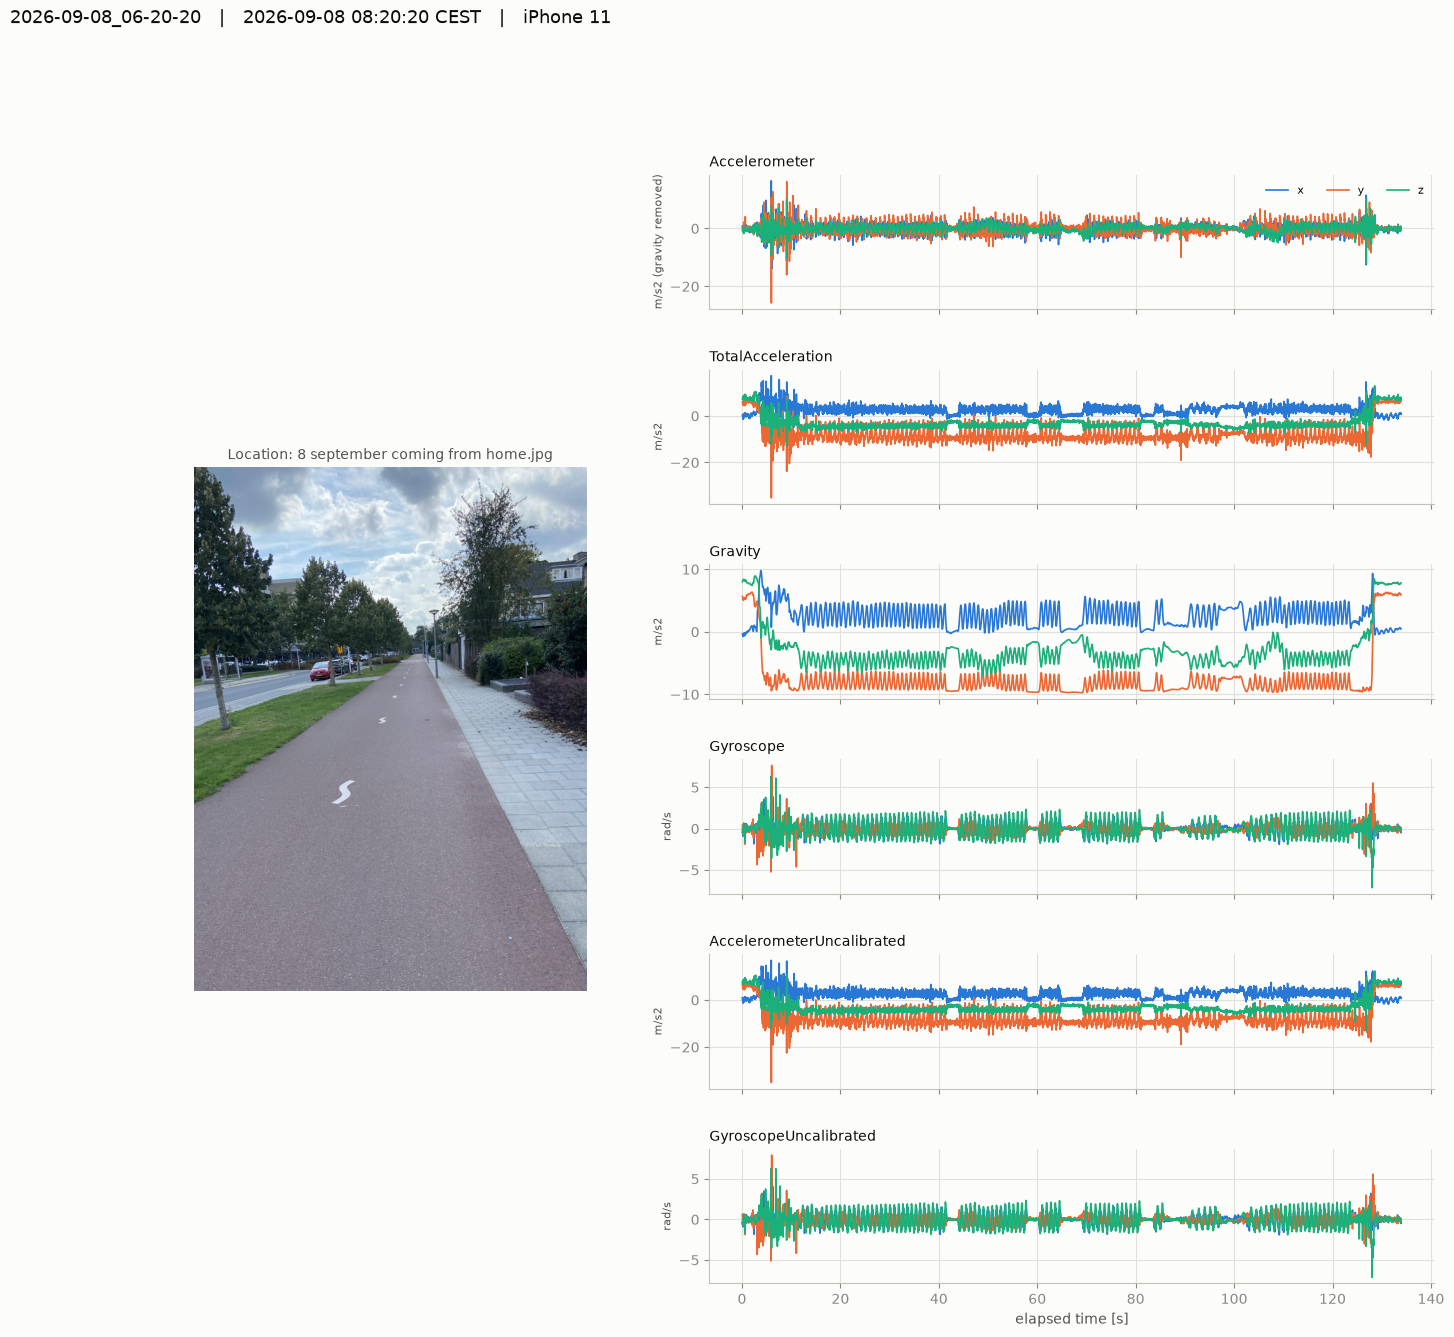

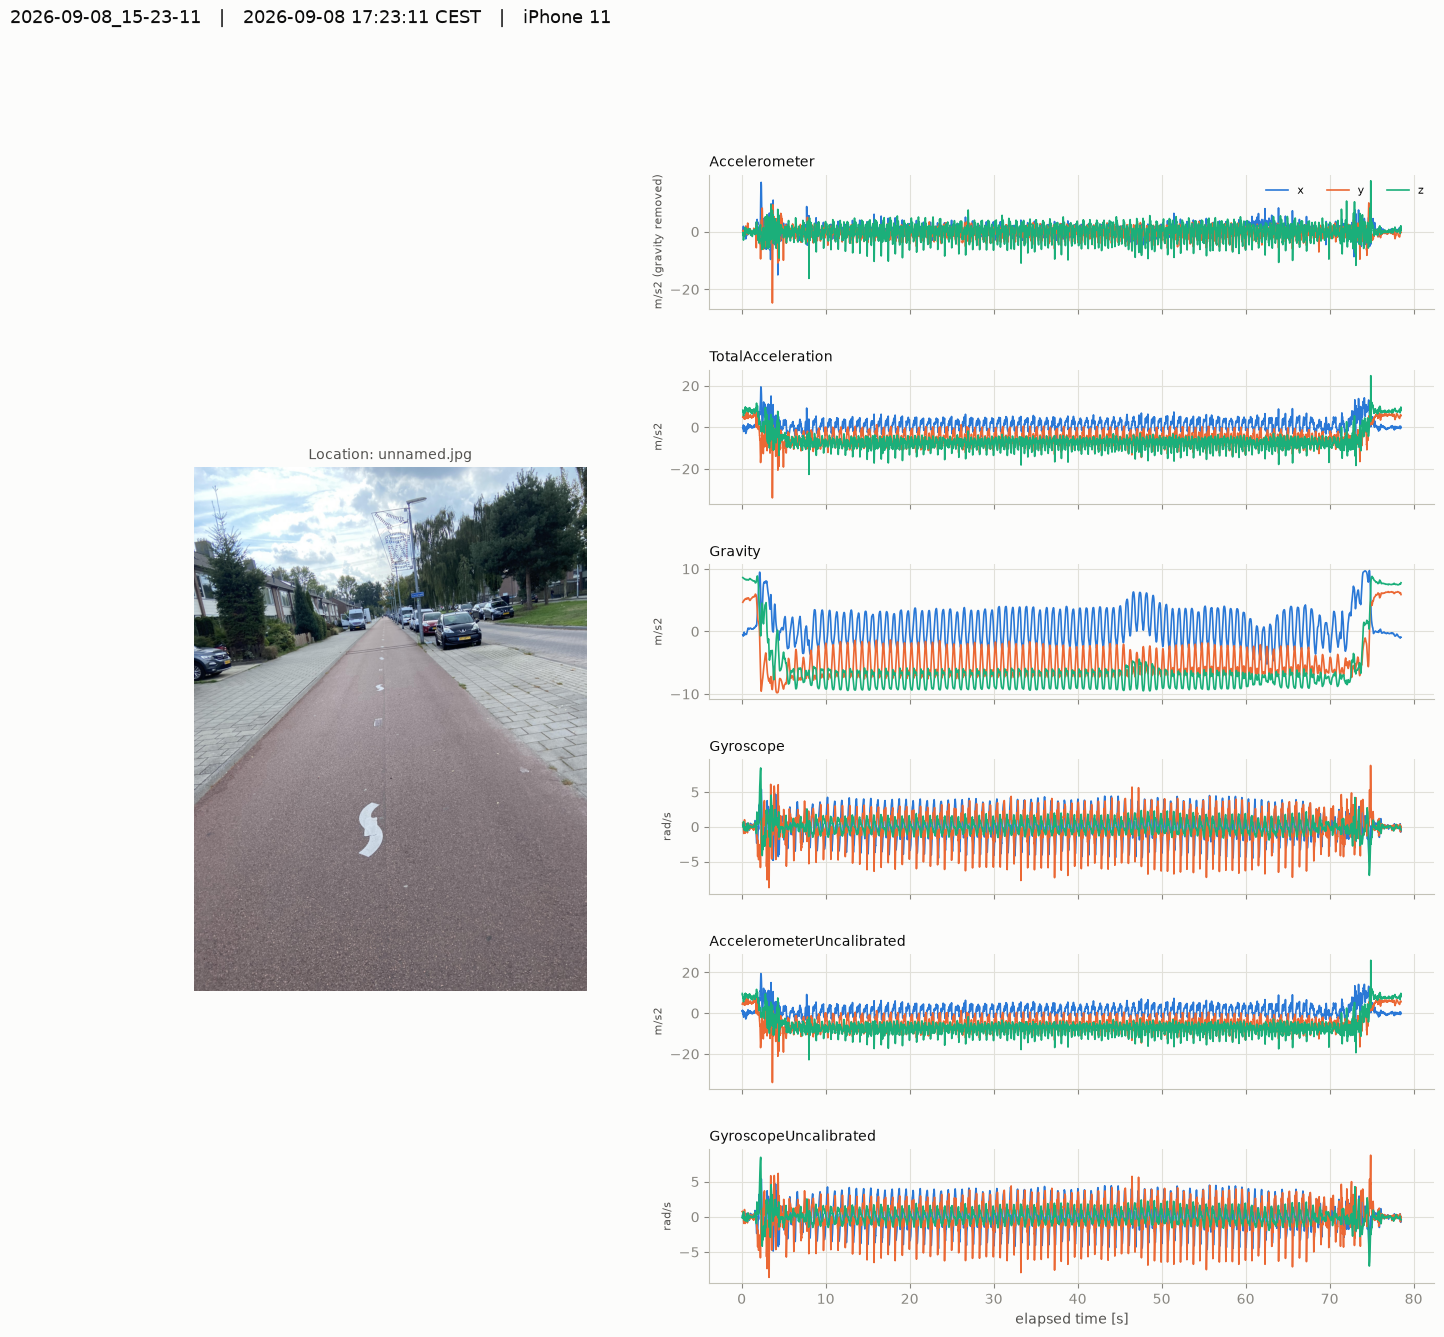

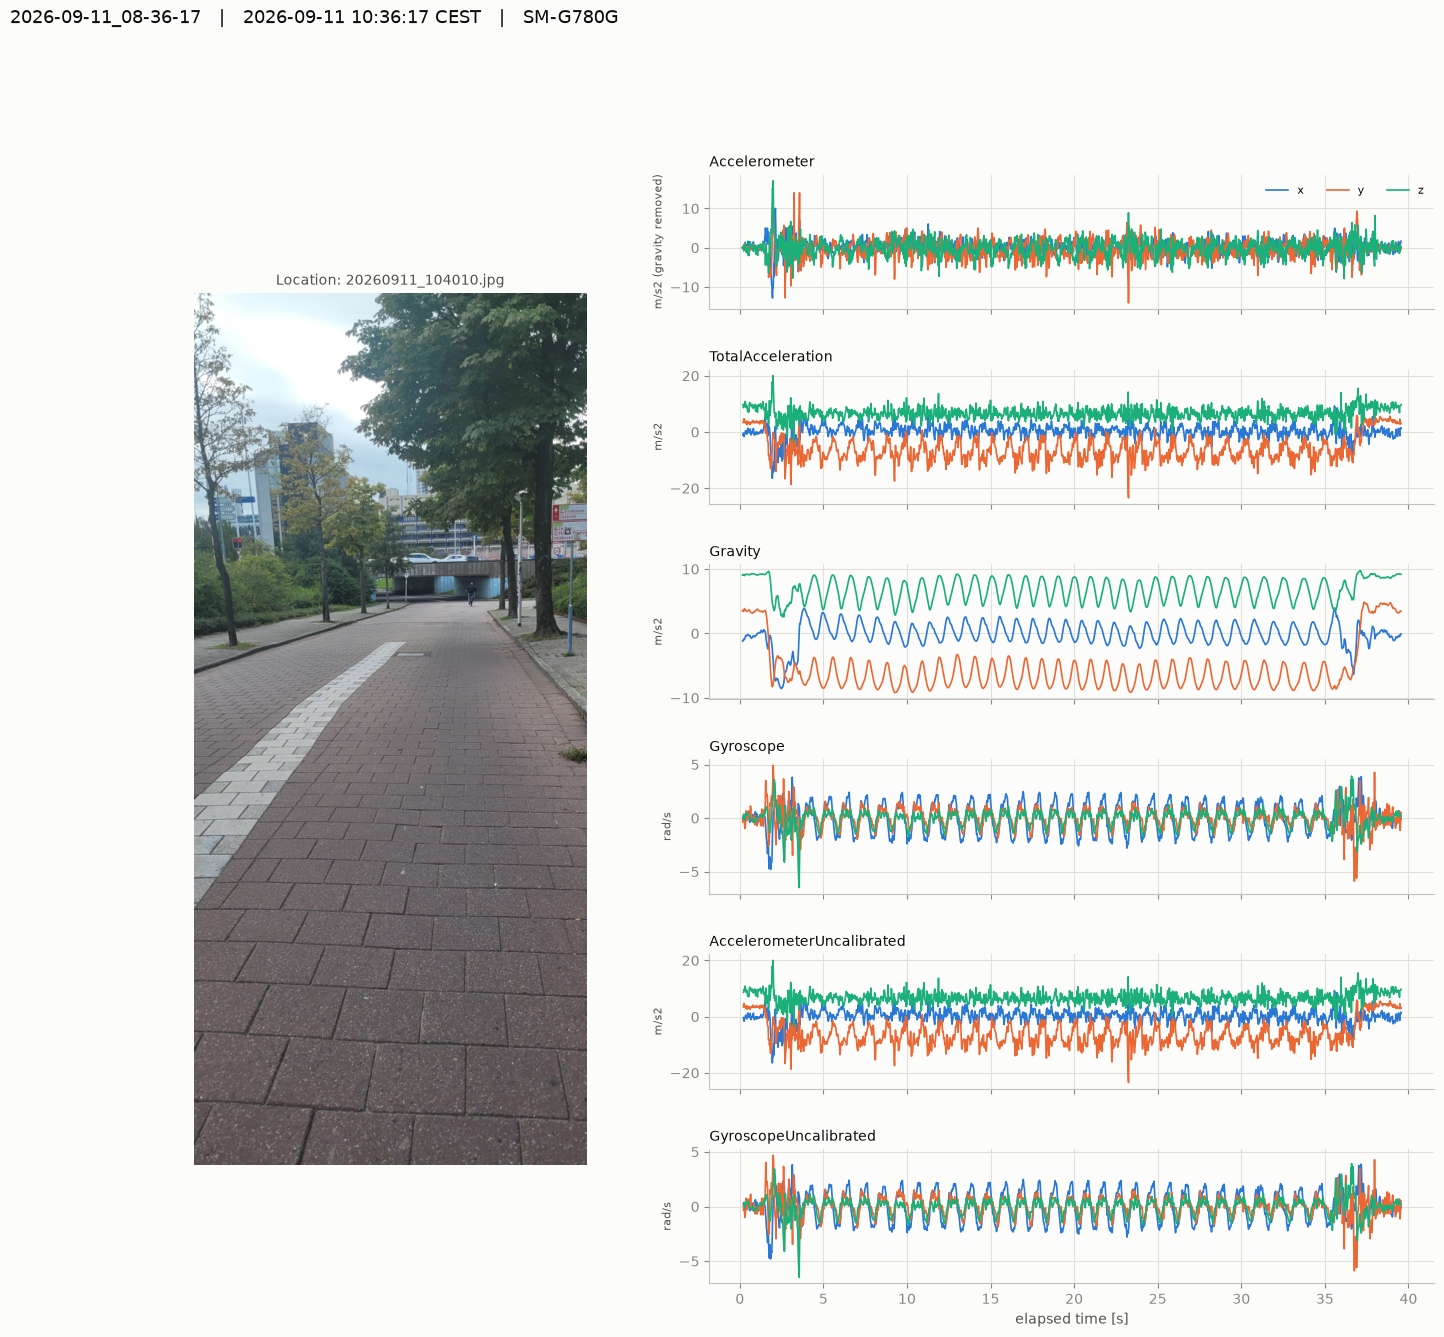

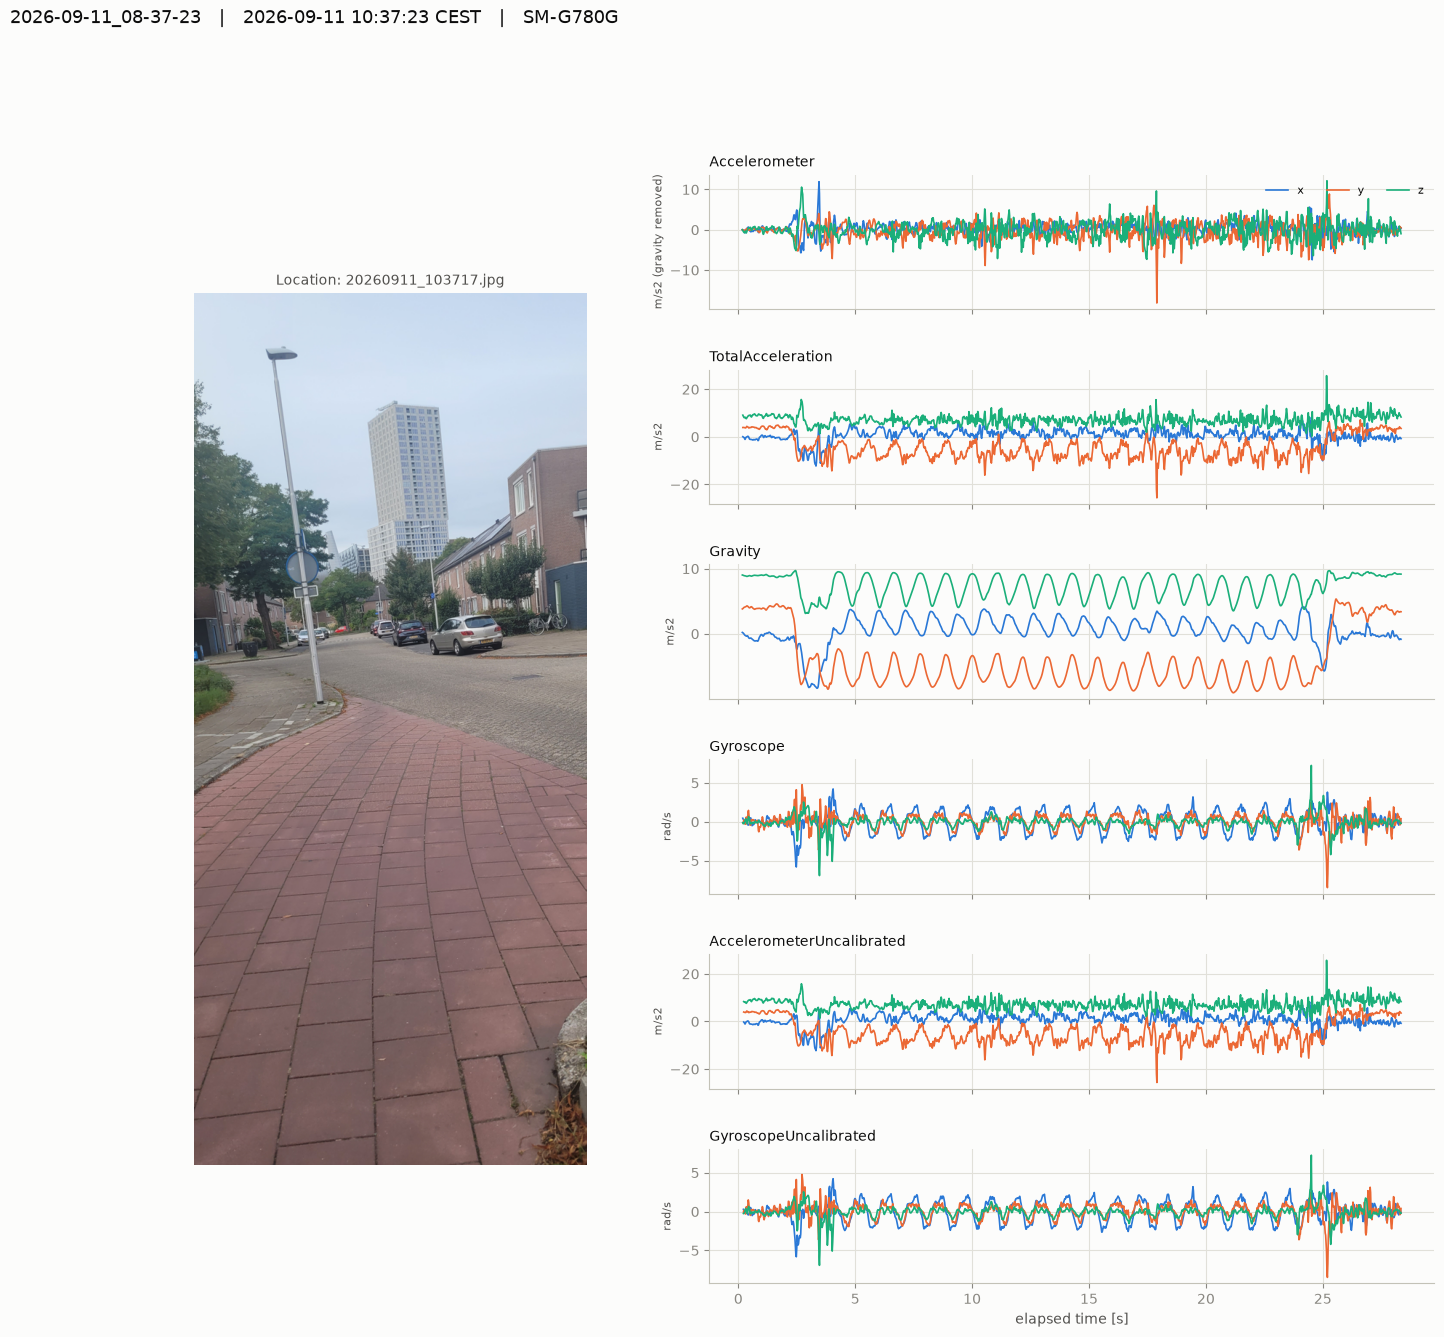

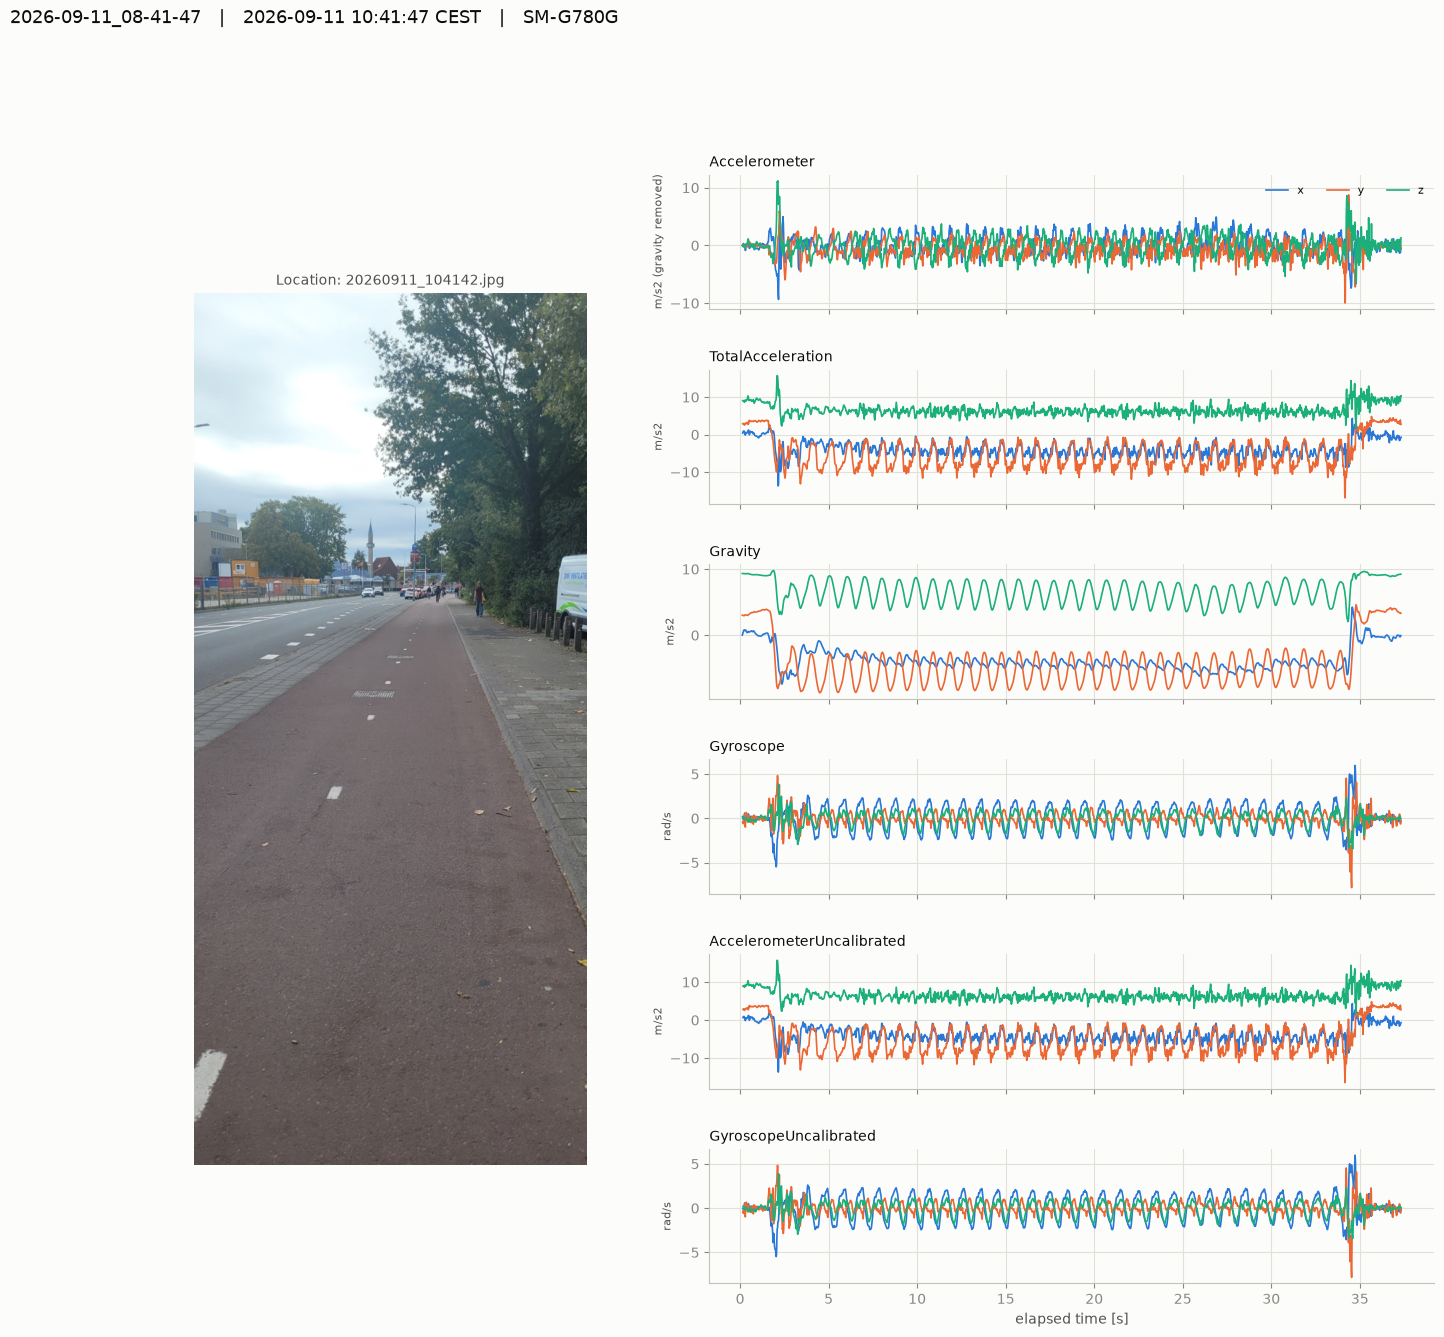

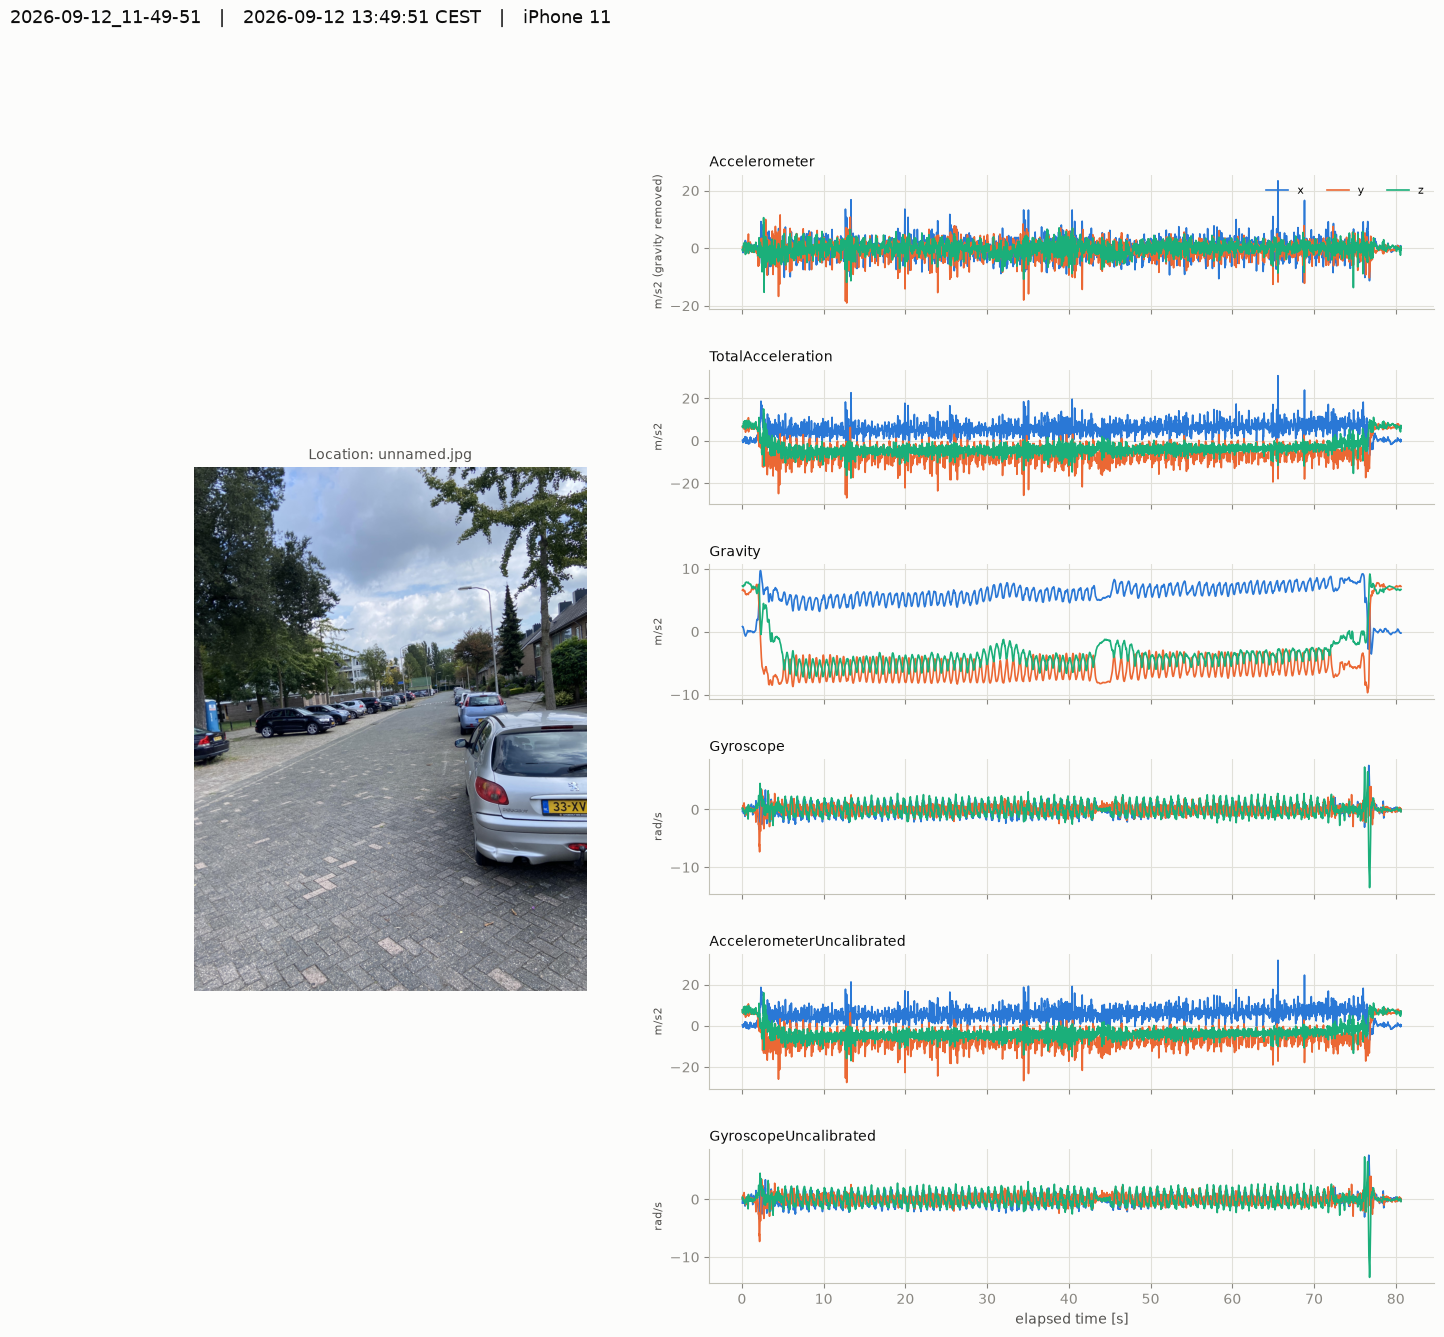

In [9]:
def plot_dataset(d: dict, sensors=None, save=True):
    """One figure per recording: photo on the left, one subplot per sensor stream on the right."""
    sensors = [s for s in (sensors or SENSORS) if s in d["sensors"]]
    n = len(sensors)

    fig = plt.figure(figsize=(16, 2.4 * n))
    gs = fig.add_gridspec(n, 2, width_ratios=[1.3, 2.4], wspace=0.22, hspace=0.45)

    # --- photo (spans all rows) ---
    ax_img = fig.add_subplot(gs[:, 0])
    if d["photo"] is not None:
        ax_img.imshow(d["photo"])
        ax_img.set_title(f"Location: {d['photo_name']}", fontsize=10, color="#52514e")
    else:
        ax_img.text(0.5, 0.5, "no photo", ha="center", va="center")
    ax_img.axis("off")

    # --- sensor streams ---
    axes = []
    for i, name in enumerate(sensors):
        ax = fig.add_subplot(gs[i, 1], sharex=axes[0] if axes else None)
        df = d["sensors"][name]
        for axis in "xyz":
            ax.plot(df["t"], df[axis], color=AXIS_COLORS[axis], label=axis)
        ax.set_ylabel(SENSORS[name], fontsize=8)
        ax.set_title(name, fontsize=10, loc="left", color="#0b0b0b")
        if i == 0:
            ax.legend(loc="upper right", ncol=3, frameon=False, fontsize=8)
        if i < n - 1:
            ax.tick_params(labelbottom=False)
        axes.append(ax)
    axes[-1].set_xlabel("elapsed time [s]")

    fig.suptitle(
        f"{d['name']}   |   {d['start'].strftime('%Y-%m-%d %H:%M:%S %Z')}   |   {d['meta']['device name']}",
        fontsize=13, x=0.01, ha="left", y=0.995, color="#0b0b0b",
    )
    if save:
        fig.savefig(FIG_DIR / f"{d['name']}_overview.png", dpi=120, bbox_inches="tight")
    plt.show()


for d in datasets:
    plot_dataset(d)


## 4. Compare the datasets side by side

- Top row: the location photo of each dataset. 
- Bottom row: magnitude of the total acceleration
$|a| = \sqrt{x^2+y^2+z^2}$, on a shared y-axis so the vibration level of the different
locations can be compared directly.

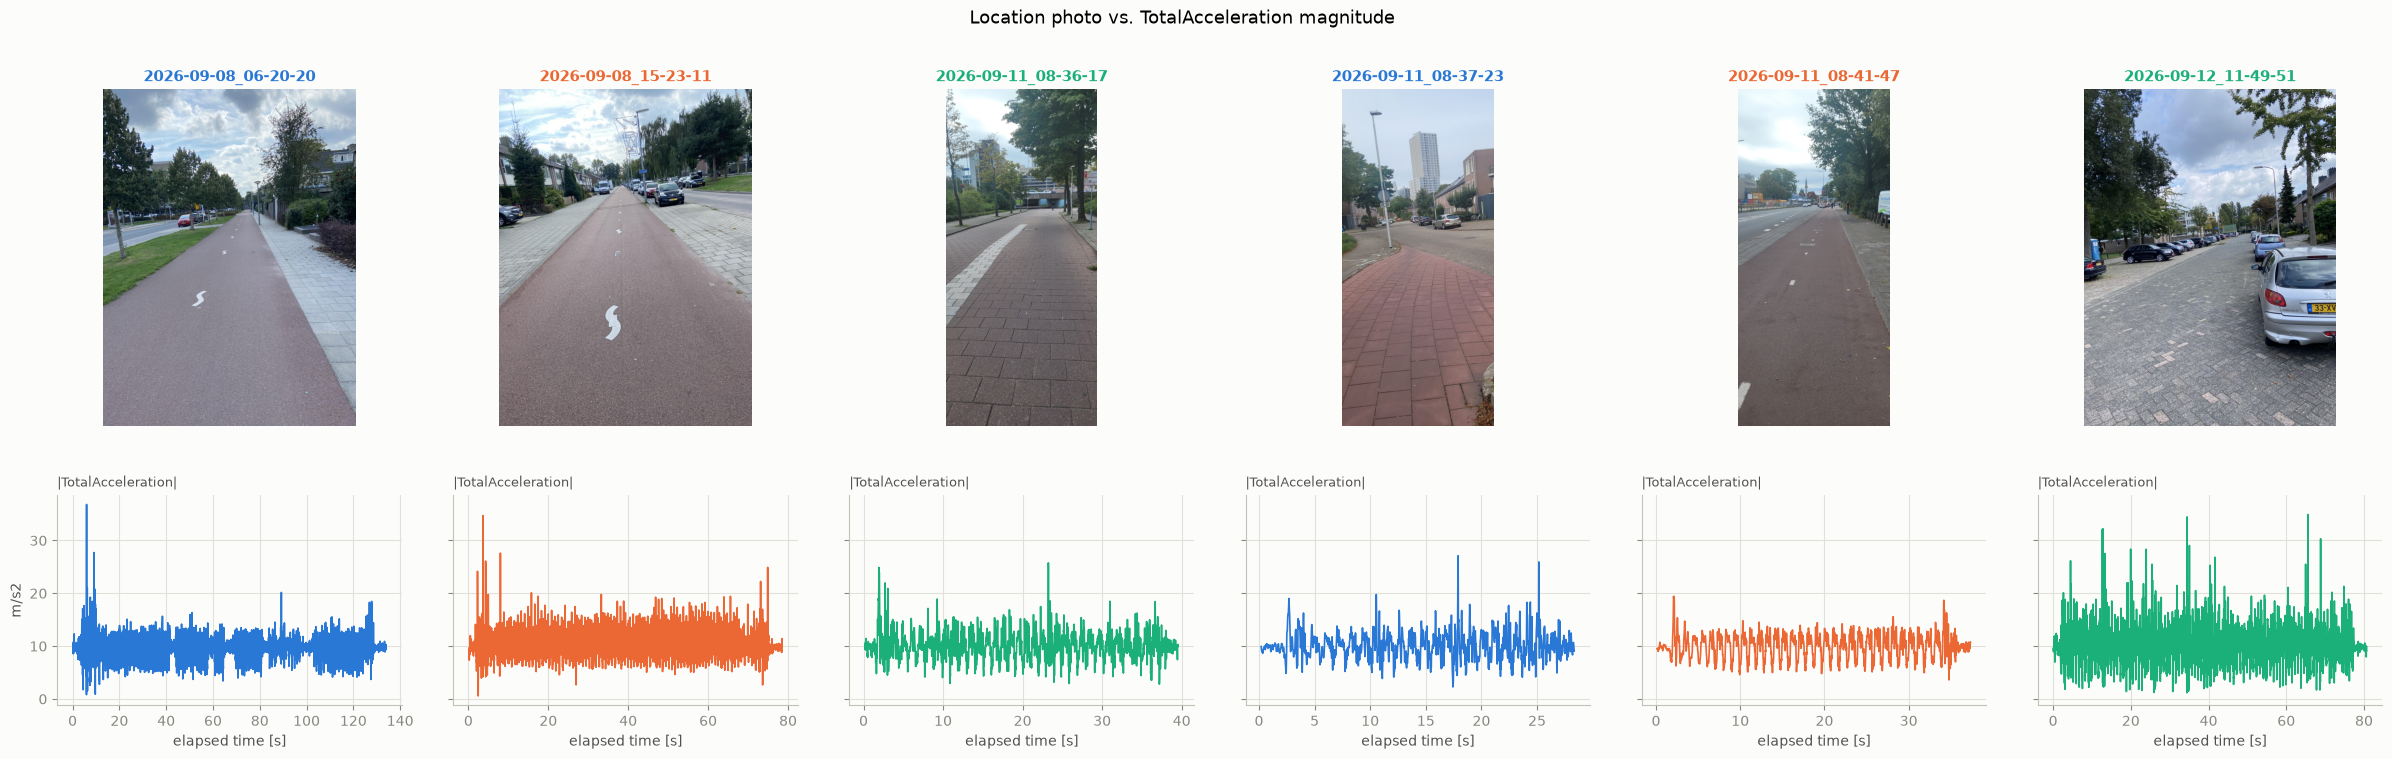

In [10]:
def magnitude(df):
    return np.sqrt(df["x"] ** 2 + df["y"] ** 2 + df["z"] ** 2)


def plot_comparison(datasets, sensor="TotalAcceleration", save=True):
    n = len(datasets)
    fig, axes = plt.subplots(
        2, n, figsize=(5 * n, 8),
        gridspec_kw={"height_ratios": [1.6, 1], "hspace": 0.25, "wspace": 0.15},
        sharey="row",
    )
    axes = np.atleast_2d(axes).reshape(2, n)

    for i, d in enumerate(datasets):
        color = PALETTE[i % len(PALETTE)]

        ax_img = axes[0, i]
        if d["photo"] is not None:
            ax_img.imshow(d["photo"])
        ax_img.axis("off")
        ax_img.set_title(d["name"], fontsize=11, color=color, fontweight="bold")

        ax = axes[1, i]
        df = d["sensors"][sensor]
        ax.plot(df["t"], magnitude(df), color=color)
        ax.set_xlabel("elapsed time [s]")
        ax.set_title(f"|{sensor}|", fontsize=9, loc="left", color="#52514e")
        if i == 0:
            ax.set_ylabel(SENSORS[sensor])

    fig.suptitle(f"Location photo vs. {sensor} magnitude", fontsize=13, y=0.98)
    if save:
        fig.savefig(FIG_DIR / f"comparison_{sensor}.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_comparison(datasets, "TotalAcceleration")


### Vibration statistics per location

Standard deviation of the (gravity-free) accelerometer magnitude is a simple proxy for how
rough each location was.

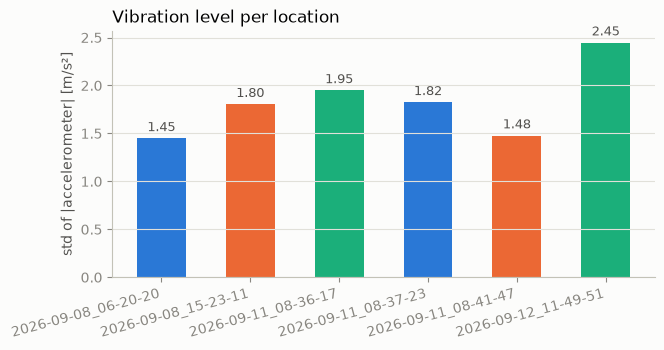

,acc |a| mean [m/s²],acc |a| std [m/s²],acc |a| max [m/s²],gyro |ω| std [rad/s]
dataset,,,,
2026-09-08_06-20-20,2.070,1.449,27.035,0.741
2026-09-08_15-23-11,3.079,1.805,26.540,1.590
2026-09-11_08-36-17,3.028,1.949,21.676,0.879
2026-09-11_08-37-23,2.758,1.825,18.406,0.992
2026-09-11_08-41-47,2.483,1.478,13.060,0.968
2026-09-12_11-49-51,3.649,2.447,25.670,0.972


In [11]:
stats = []
for d in datasets:
    acc = d["sensors"]["Accelerometer"]
    gyr = d["sensors"]["Gyroscope"]
    stats.append({
        "dataset": d["name"],
        "acc |a| mean [m/s²]": magnitude(acc).mean(),
        "acc |a| std [m/s²]": magnitude(acc).std(),
        "acc |a| max [m/s²]": magnitude(acc).max(),
        "gyro |ω| std [rad/s]": magnitude(gyr).std(),
    })
stats_df = pd.DataFrame(stats).set_index("dataset").round(3)

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.bar(stats_df.index, stats_df["acc |a| std [m/s²]"],
              color=PALETTE[: len(stats_df)], width=0.55)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color="#52514e")
ax.set_ylabel("std of |accelerometer| [m/s²]")
ax.set_title("Vibration level per location", loc="left")
ax.grid(axis="x", visible=False)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.savefig(FIG_DIR / "vibration_per_location.png", dpi=120, bbox_inches="tight")
plt.show()

stats_df
